# **Notebook 14 – Model Evaluation – Classification**

In [22]:
# Import Libraries 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score


In [23]:
# Load Dataset 
df = pd.read_csv("credit_card_default_classification.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          2000 non-null   int64  
 1   Age                  2000 non-null   int64  
 2   Annual_Income        2000 non-null   int64  
 3   Credit_Score         2000 non-null   int64  
 4   Loan_Amount          2000 non-null   int64  
 5   Debt_to_Income       2000 non-null   float64
 6   Payment_Delay_Count  2000 non-null   int64  
 7   Default              2000 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 125.1+ KB


## **1. Confusion Matrix**

**Understand the Concept**

- A Confusion Matrix shows the correct and incorrect predictions of a classification model.
- It compares actual values with predicted values.
- It contains four parts: TP, TN, FP, and FN.

**How It Works**

- Actual Yes + Predicted Yes → True Positive.
- Actual No + Predicted No → True Negative.
- Actual No + Predicted Yes → False Positive.
- Actual Yes + Predicted No → False Negative.



In [24]:
X = df[["Age","Annual_Income","Credit_Score","Loan_Amount","Debt_to_Income","Payment_Delay_Count"]]
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [25]:
cm = confusion_matrix(y_test,y_pred,labels=["Yes", "No"])
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 37  40]
 [ 22 301]]


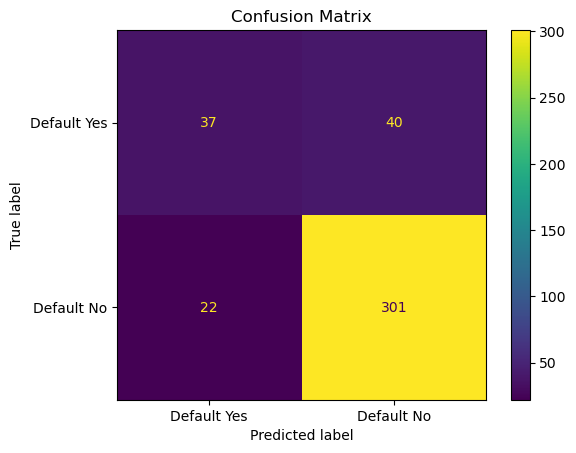

In [26]:
display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Default Yes", "Default No"])
display.plot()
plt.title("Confusion Matrix")
plt.show()

## **2. True Positive (TP)**

**Understand the Concept**

- True Positive means the model correctly predicts the positive class.
- In our dataset, positive class means Default = Yes.
- The customer actually defaults and the model predicts Yes.

**Example**

- Actual: Default Yes.
- Predicted: Default Yes.

In [27]:
true_positive = cm[0, 0]
print("True Positive:", true_positive)

True Positive: 37


## **3. True Negative (TN)**

**Understand the Concept**

- True Negative means the model correctly predicts the negative class.
- Here, negative class means Default = No.
- The customer does not default and the model predicts No.

**Example**

- Actual: Default No.
- Predicted: Default No.

In [28]:
true_negative = cm[1, 1]
print("True Negative:", true_negative)

True Negative: 301


## **4. False Positive (FP)**

**Understand the Concept**

- False Positive means the model predicts positive, but the actual value is negative.
- Here, the model predicts Default = Yes, but the actual value is No.

**Example**

- Actual: Default No.
- Predicted: Default Yes.

In [29]:
false_positive = cm[1, 0]
print("False Positive:", false_positive)

False Positive: 22


## **5. False Negative (FN)**

**Understand the Concept**

- False Negative means the model predicts negative, but the actual value is positive.
- Here, the customer defaults, but the model predicts No.

**Example**

- Actual: Default Yes.
- Predicted: Default No.

In [30]:
false_negative = cm[0, 1]
print("False Negative:", false_negative)

False Negative: 40


## **6. Accuracy**

**Understand the Concept**

- Accuracy shows the percentage of correct predictions.
- It considers both positive and negative predictions.
- Higher accuracy means more correct predictions.

**Formula**

Accuracy = (TP + TN) / (TP + TN + FP + FN)

**Example**

- If 90 out of 100 predictions are correct, accuracy is 90%.



In [31]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.845


## **7. Precision**

**Understand the Concept**

- Precision shows how many predicted positive cases were actually positive.
- It focuses on False Positives.
- Higher precision means fewer false alarms.

**Formula**

Precision = TP / (TP + FP)

**Example**

- The model predicts 10 customers will default.
- If 8 actually default, precision is 80%.


In [32]:
from sklearn.metrics import precision_score

precision = precision_score(y_test,y_pred,pos_label="Yes")
print("Precision:", precision)

Precision: 0.6271186440677966


## **8. Recall**

**Understand the Concept**

- Recall shows how many actual positive cases were correctly found.
- It focuses on False Negatives.
- Higher recall means fewer positive cases are missed.

**Formula**

Recall = TP / (TP + FN)

**Example**

- There are 10 actual default customers.
- If the model finds 8, recall is 80%.



In [33]:
from sklearn.metrics import recall_score

recall = recall_score(y_test,y_pred,pos_label="Yes")
print("Recall:", recall)

Recall: 0.4805194805194805


## **9. Specificity**

**Understand the Concept**

- Specificity shows how many actual negative cases were correctly identified.
- It focuses on True Negatives.
- Higher specificity means fewer False Positives.

**Formula**

Specificity = TN / (TN + FP)

**Example**

- There are 100 actual negative cases.
- If the model correctly identifies 90, specificity is 90%.


In [34]:
specificity = true_negative / (true_negative + false_positive)
print("Specificity:", specificity)

Specificity: 0.9318885448916409


## **10. F1 Score**

**Understand the Concept**

- F1 Score combines Precision and Recall.
- It gives a single score based on both metrics.
- Higher F1 Score means a better balance between Precision and Recall.

**Formula**

F1 Score = 2 × (Precision × Recall) / (Precision + Recall)

**Example**

- A model with good Precision and Recall will have a higher F1 Score.
- A low Precision or Recall can reduce the F1 Score.


In [35]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test,y_pred,pos_label="Yes")
print("F1 Score:", f1)

F1 Score: 0.5441176470588235


## **11. ROC Curve**

**Understand the Concept**

- ROC Curve shows how the model performs at different classification thresholds.
- It compares True Positive Rate and False Positive Rate.
- A better ROC Curve stays closer to the top-left corner.

**Formula**

True Positive Rate = TP / (TP + FN)

False Positive Rate = FP / (FP + TN)

**Example**

- The threshold changes how many positive and negative predictions are made.
- ROC Curve shows this change across different thresholds.

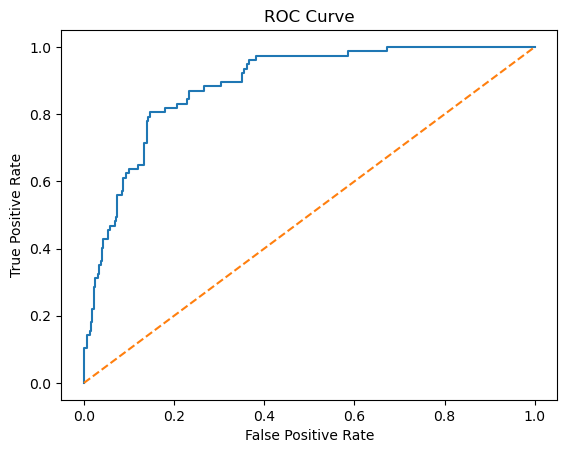

In [36]:
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_test_binary = (y_test == "Yes").astype(int)

fpr, tpr, thresholds = roc_curve(y_test_binary,y_prob)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## **12. AUC**

**Understand the Concept**

- AUC means Area Under the ROC Curve.
- It shows how well the model separates the two classes.
- A higher AUC means better class separation.

**Formula**

AUC = Area under the ROC Curve

**Example**

- AUC close to 1 means good class separation.
- AUC around 0.5 means the model has little class separation.



In [37]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test_binary,y_prob)
print("AUC:", auc)

AUC: 0.887378874994974


## **13. Precision-Recall Curve**

**Understand the Concept**

- Precision-Recall Curve shows the relationship between Precision and Recall at different thresholds.
- It is especially useful for imbalanced datasets.
- It helps understand the trade-off between Precision and Recall.

**Example**

- Increasing Recall may reduce Precision.
- The curve shows this trade-off at different thresholds.



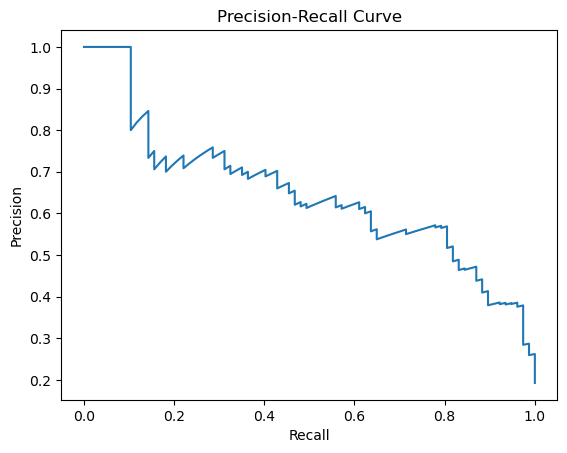

In [38]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(y_test_binary,y_prob)
plt.plot(recall_values, precision_values)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

**Explanation**

- The curve shows the trade-off between Precision and Recall.
- It is useful when the classes are imbalanced.
- It helps choose a suitable classification threshold.

**Why Accuracy Alone Is Not Enough**

- Accuracy can look high when one class is much larger than the other.
- It may hide False Positives and False Negatives.
- Precision, Recall, Specificity and F1 Score give more details.
- For imbalanced data, we should look at multiple evaluation metrics.